# Movie Review Sentiment Analysis and Rating Prediction

In this homework, you will:
1. Load IMDB movie reviews dataset using Hugging Face datasets
2. Perform sentiment analysis
3. Build a ML model to predict movie ratings


In [ ]:
# TODO: Install required packages
%pip install pandas numpy scikit-learn transformers torch datasets

In [ ]:
# TODO: Import required libraries
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')
# Add any other libraries you need

## Part 1: Load Dataset

Load the IMDB dataset using Hugging Face datasets library

In [ ]:
# TODO: Load the IMDB dataset
# Hint: Use load_dataset('imdb')
load_dataset('imdb')
# Convert to pandas DataFrame for easier manipulation
imdb_dataset = load_dataset('imdb')
train_df = pd.DataFrame(imdb_dataset['train'])
test_df = pd.DataFrame(imdb_dataset['test'])


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

## Part 2: Data Preprocessing

Clean and prepare the text data

In [ ]:
# TODO: Create a function to clean text
# Hint: Use regular expressions

def clean_text(text):
  text = re.sub(r'<.*?>', '', text)           # 1. Remove HTML tags
  text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # 2. Remove special characters
  text = text.lower()                         # 3. Convert to lowercase
  text = ' '.join(text.split())               # removes extra whitespace
  return text


## Part 3: Advanced Sentiment Analysis

Go beyond binary classification - use a pre-trained model to get continuous sentiment scores

In [ ]:
# TODO: Implement advanced sentiment analysis
from transformers import pipeline

# 1. Load a pre-trained model (hint: try 'distilbert-base-uncased-finetuned-sst-2-english')
sentiment_analyzer = pipeline('sentiment-analysis',model='distilbert-base-uncased-finetuned-sst-2-english',truncation=True,max_length=512)

# 2. Create a function to get continuous sentiment scores
def get_sentiment_score(text):
  try:
    text = text[:2000]    # limits text to avoid token limit
    sentiment = sentiment_analyzer(text)[0]
    if sentiment['label'] == 'POSITIVE':
      return sentiment['score']   # Positive reviews get higher scores
    else:
      return 1 - sentiment['score'] # Negative reviews get lower scores
  except Exception as e:
    return 0.5    # Gives neutral score if errors

# 3. Apply it to your cleaned text data
# sample a fraction of data for faster processing
fraction = 0.04
train_subset = train_df.sample(frac=fraction, random_state=42)
test_subset = test_df.sample(frac=fraction, random_state=42)

# Apply sentiment scoring using subset
train_subset['sentiment_score'] = train_subset['text'].apply(get_sentiment_score)
test_subset['sentiment_score'] = test_subset['text'].apply(get_sentiment_score)

# Note: Original dataset has binary labels, but we want continuous scores!

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


## Part 4: Feature Engineering

Create rich features for your model

In [ ]:
# TODO: Create features

# 1. Use your continuous sentiment scores
# Done above in Part 3

# 2. Calculate text statistics:
def calculate_statistics(text):
  # takes care of NaN or non string values
  if pd.isna(text) or not isinstance(text, str):
    return pd.Series({'text_length': 0, 'word_count': 0, 'avg_word_length': 0, 'sentence_count': 0})

  cleaned = clean_text(text)
#    - Length
  length = len(cleaned)
#    - Word count
  words = cleaned.split()
  word_count = len(words)
#    - Average word length
  avg_word_length = sum(len(word) for word in words) / word_count
#    - Sentence count
  sentences = re.split(r'[.!?]', text)
  sentence_count = len([s for s in sentences if s.strip()])

  return pd.Series({'text_length': length, 'word_count': word_count, 'avg_word_length': avg_word_length, 'sentence_count': sentence_count})

# Get the features
text_features = train_subset['text'].iloc[:, 0].apply(calculate_statistics)
train_subset[['text_length', 'word_count', 'avg_word_length', 'sentence_count']] = text_features

# 3. Any other features you think might help!
# Adding exclamation marks - Means they're pissed!!!
train_subset['exclamation_count'] = train_subset['text'].iloc[:, 0].apply(lambda x: x.count('!') if isinstance(x, str) else 0)


print(train_subset[['sentiment_score', 'text_length', 'word_count', 'avg_word_length', 'sentence_count', 'exclamation_count']].head())

       sentiment_score  text_length  word_count  avg_word_length  \
6868          0.001132        624.0       114.0         4.482456   
24016         0.999728        780.0       143.0         4.461538   
9668          0.001355       1234.0       219.0         4.639269   
13640         0.010378        761.0       149.0         4.114094   
14018         0.998627       1965.0       345.0         4.698551   

       sentence_count  exclamation_count  
6868              7.0                  0  
24016            10.0                  0  
9668             10.0                  0  
13640             8.0                  0  
14018            14.0                  3  


In [ ]:
# Check first few rows to review sentiment scores
print(train_subset[['label', 'sentiment_score']].head())
print(train_subset['text'].iloc[1, 0])

       label  sentiment_score
6868     0.0         0.001132
24016    1.0         0.999728
9668     0.0         0.001355
13640    1.0         0.010378
14018    1.0         0.998627
I dug out from my garage some old musicals and this is another one of my favorites. It was written by Jay Alan Lerner and directed by Vincent Minelli. It won two Academy Awards for Best Picture of 1951 and Best Screenplay. The story of an American painter in Paris who tries to make it big. Nina Foch is a sophisticated lady of means and is very interested in helping him, but soon finds she loves the guy. Meanwhile Gene Kelly falls for lovely damsel, Leslie Caron. His main dancing partner, and I must say they are fantastic together on the floor and otherwise. Famous French singer Georges Guietary sings, too. So if you like good smooth dancing and fun filled scenes filled with Oscar Levant's nimble piano fingers, the songs of George Gershwyn will live on forever in this colorful gem. 8/10


## Part 5: Multi-Class Rating Prediction

Instead of binary classification, predict a 5-star rating!

In [ ]:
# TODO: Create target variable
# Convert binary labels to 5-star ratings using your features
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = [1, 2, 3, 4, 5]
# Hint: Use sentiment scores and other features to estimate star rating
train_subset['rating'] = pd.cut(train_subset['sentiment_score'], bins=bins, labels=labels)

target_variable = 'rating'

print(train_subset[['label', 'sentiment_score', 'rating']].head())
print()
print(train_subset['rating'].value_counts().sort_index())

       label  sentiment_score rating
6868     0.0         0.001132      1
24016    1.0         0.999728      5
9668     0.0         0.001355      1
13640    1.0         0.010378      1
14018    1.0         0.998627      5

rating
1    516
2     22
3      9
4     12
5    441
Name: count, dtype: int64


In [ ]:
# TODO: Build and train your model
# 1. Split data into train and test sets
X = train_subset[['sentiment_score', 'text_length', 'word_count', 'avg_word_length', 'sentence_count', 'exclamation_count']]
y = train_subset[target_variable]

# Handle NaN values
X = X.fillna(0)
y = y.dropna()
X = X.loc[y.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Choose a model suitable for multi-class classification
model = LogisticRegression(multi_class='multinomial', solver='lbfgs')

# 3. Train the model
model.fit(X_train, y_train)

# 4. Make predictions
y_pred = model.predict(X_test)

# 5. Evaluate performance
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

              precision    recall  f1-score   support

           1       0.84      0.90      0.87        99
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         2
           5       0.86      0.83      0.85        96

    accuracy                           0.84       200
   macro avg       0.34      0.35      0.34       200
weighted avg       0.83      0.84      0.84       200

Accuracy: 0.845


## Part 6: Analysis

Analyze your results and suggest improvements

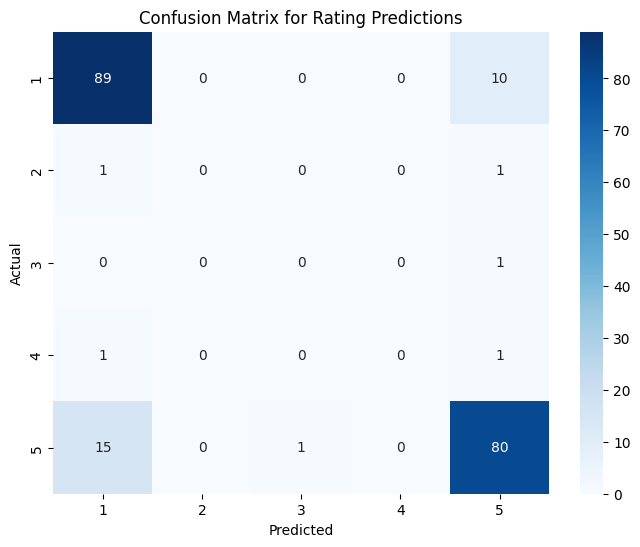

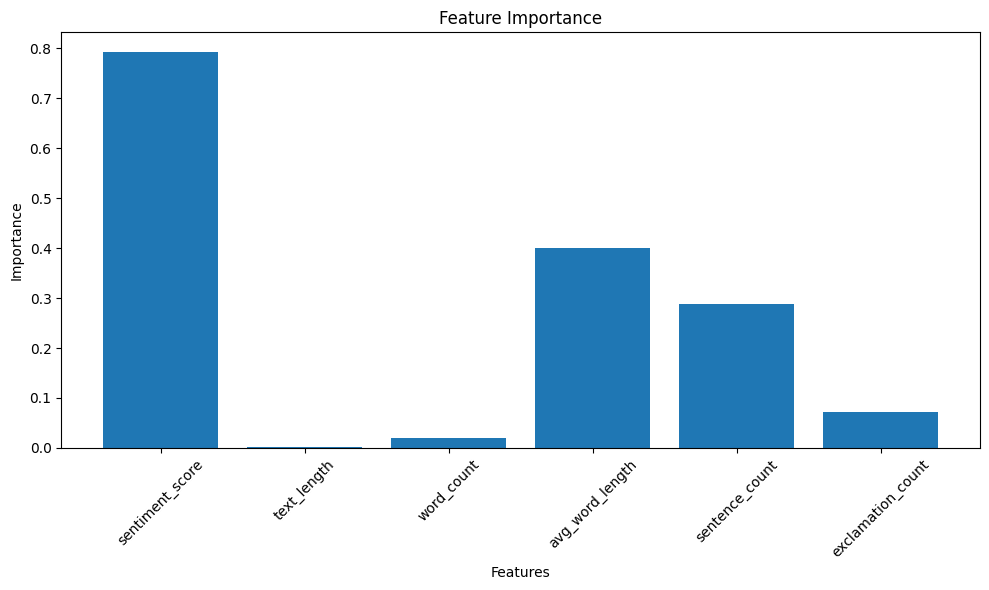


rating
1    99
2     2
3     1
4     2
5    96
Name: count, dtype: int64


In [ ]:
# TODO: Create visualizations and analyze:
# 1. Confusion matrix for multi-class predictions
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for Rating Predictions')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print()

# 2. Feature importance
feature_names = ['sentiment_score', 'text_length', 'word_count', 'avg_word_length', 'sentence_count', 'exclamation_count']
importance = abs(model.coef_[0])
plt.figure(figsize=(10, 6))
plt.bar(feature_names, importance)
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print()

# 3. Error analysis
print(y_test.value_counts().sort_index())
# My model tends to give the majority of ratings a 1 or 5, struggling to identify the ratings in the middle
# It knows the really bad and really good reviews, but doesn't detect much nuance.

# 4. Suggest improvements
# I could try a better model like random forest
# Modify the bins for the ratings to get more balanced classes
# Use SMOTE or class weights to deal with the imbalanced classes